In [1]:
import sys
sys.path.insert(0, '..')

import numpy  as np
import tensorflow as tf
import math
import pandas as pd

from model.data import getDataETTh1
from model.model import myInformer

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

(1000, 96, 7)
training True
(32, 96, 512)
training True
prediction (32, 24, 7)
(24,)


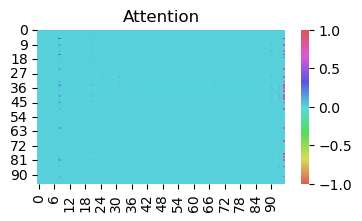

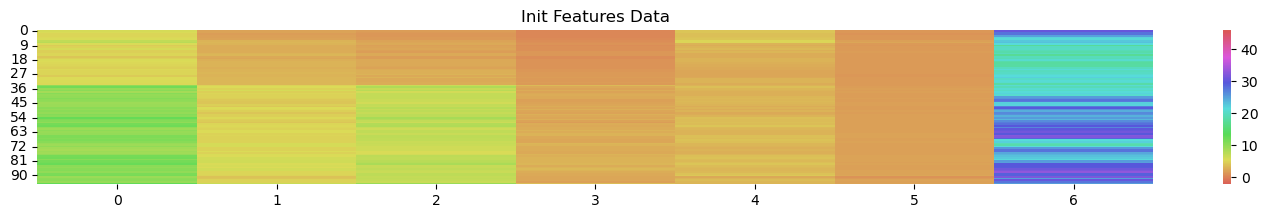

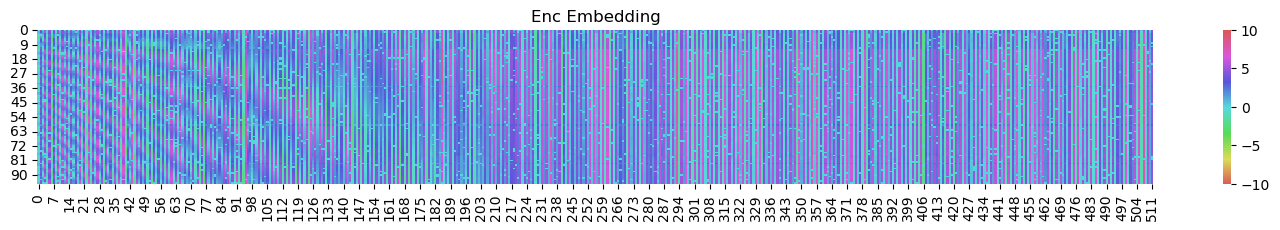

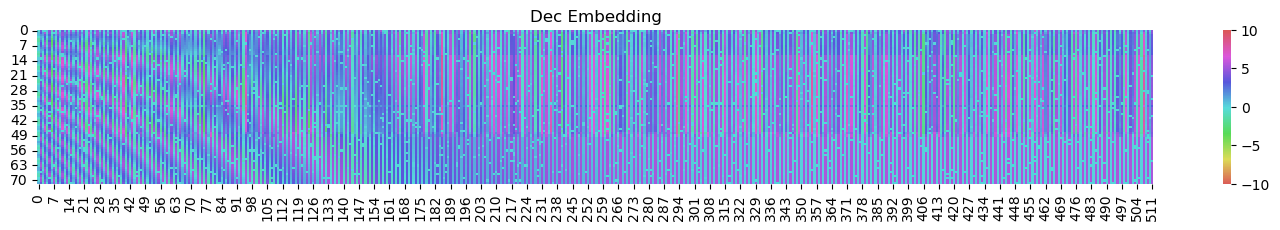

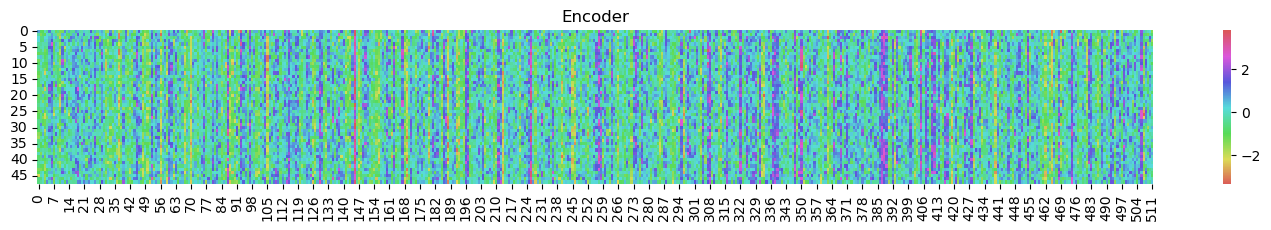

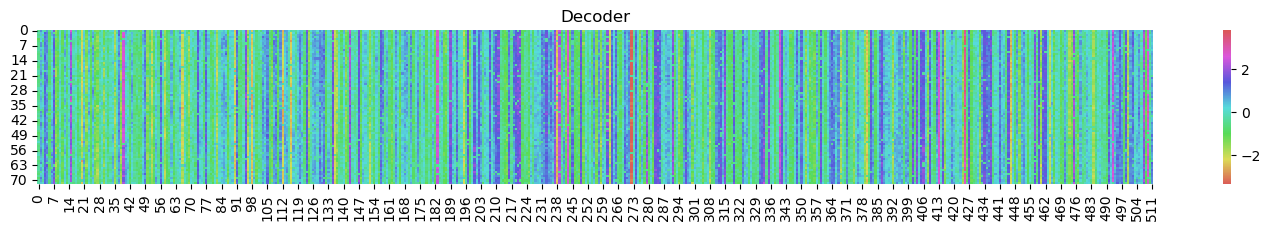

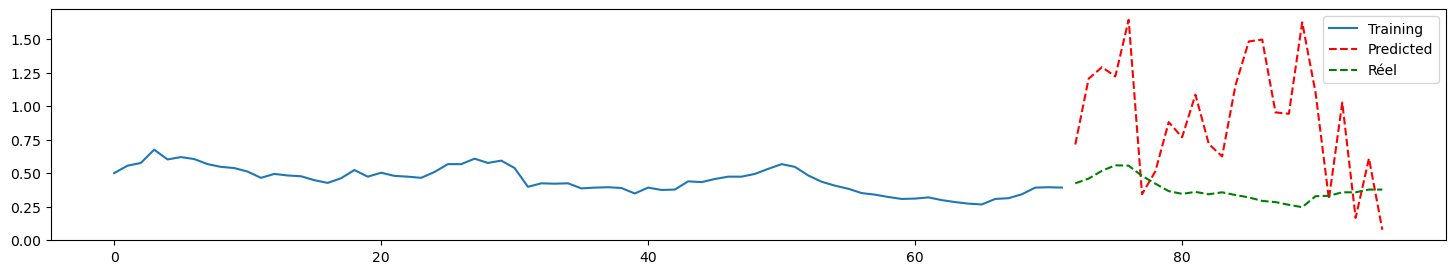

In [3]:
# Model
d_model = 512
HEADS = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 1000
N = 2
d_ff= 2048

PRED_LEN =24

tf.keras.backend.clear_session()

myModelFct = myInformer(
    seq_len=SEQ_LEN, pred_len=PRED_LEN,batch_size=BATCH_SIZE,d_model=d_model,rate=RATE,factor=FACTOR,head=HEADS,d_ff=d_ff,
    e_layer=N,features=7
)

# Get DATA
dataFct = getDataETTh1(SEQ_LEN,GLOBAL_SIZE)
x, x_date, Yt, YtDate, df_raw = dataFct.get()

print(x.shape)

start = np.random.randint(0,GLOBAL_SIZE-BATCH_SIZE)
pred, outDec, outEnc, decEmb, encEmb, attn, xN, x_dateN, x_enc = myModelFct(x,x_date,start)

outInf = pred[:,-24:,:]
print('prediction',outInf.shape)
print(outInf[0,:,-1].shape)
# print(x_enc[0,-48:-24,-1].shape)
# df = pd.DataFrame(np.vstack((outInf[0,:,-1],x_enc[0,-48:-24,-1]))) #,columns=['Pred','Vrai'])
Xt_min = tf.reduce_min(x)
Xt_max = tf.reduce_max(x)
Out_min = tf.reduce_min(pred)
Out_max = tf.reduce_max(pred)
# fig = plt.figure(figsize=(18,2))
# sns.lineplot(x=df_raw['date'][:GLOBAL_SIZE],y=df_raw['OT'][:GLOBAL_SIZE]).set_title('Data Brutes [0-32]');
# fig = plt.figure(figsize=(18,2))
# sns.lineplot(outInf[0,:,-1]).set_title('Prédictions');
fig = plt.figure(figsize=(4,2))
sns.heatmap(attn[0][0,0,:,:], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Attention');
fig = plt.figure(figsize=(18,2))
sns.heatmap(x[0,:,:], vmin=Xt_min, vmax=Xt_max, cmap=sns.color_palette("hls", 256)).set_title('Init Features Data');
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(encEmb[i,:,:], vmin=-10, vmax=10, cmap=sns.color_palette("hls", 256)).set_title('Enc Embedding');
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(decEmb[i,:,:], vmin=-10, vmax=10, cmap=sns.color_palette("hls", 256)).set_title('Dec Embedding');
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(outEnc[i,:,:], vmin=Out_min, vmax=Out_max, cmap=sns.color_palette("hls", 256)).set_title('Encoder');# for i in range(0,BATCH_SIZE,8):
for i in range(0,BATCH_SIZE,32):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(outDec[i,:,:], vmin=Out_min, vmax=Out_max, cmap=sns.color_palette("hls", 256)).set_title('Decoder');# for i in range(0,BATCH_SIZE,8):

DATA_SIZE = SEQ_LEN
LOOP = SEQ_LEN
FORCAST = PRED_LEN
x_padd = tf.zeros(shape=(BATCH_SIZE,24,7))
x_pred = tf.concat([x_padd,pred],1)

# print(xN.shape, pred.shape, x_pred.shape)
# print('-----')
# print(range(xN[start,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0]),xN[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6])
# print(range(xN[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0], LOOP),xN[0,DATA_SIZE-FORCAST:DATA_SIZE,6])
# print(range(pred[0,0:48,6].shape[0], 72),pred[0,48:72,6])
# print()
fig = plt.figure(figsize=(18,3))
plt.plot(range(x_enc[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0]),x_enc[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6], label="Training");
plt.plot(range(x_pred[0,0:72,6].shape[0], 96),x_pred[0,72:96,6], 'r--', label="Predicted");
# plt.plot(range(xN[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0], LOOP),xN[0,DATA_SIZE-FORCAST:DATA_SIZE,6], 'r--', label="Predicted");
plt.plot(range(x_enc[0,DATA_SIZE-LOOP:DATA_SIZE-FORCAST,6].shape[0], LOOP),x_enc[0,DATA_SIZE-FORCAST:DATA_SIZE,6], 'g--', label="Réel");
plt.legend();
